# Building Daily Load Profile Characterization Engine

Analyzes a building's electrical demand data to characterize daily operating behavior:
- Probable start/end times and ramp rates
- Baseline demand and operating threshold detection
- Peak shape, breadth, and peakiness metrics
- Daily load-shape classification with confidence scoring
- Data quality and provenance tracking

**Input units:** Data may be in **kW** (instantaneous demand) or **kWh** (energy per interval).  
Set `unit` in `config/analysis_config.toml → [input]`. The engine converts kWh → kW automatically using the detected interval length before any analysis runs.

**Architecture:** Raw data → unit conversion → regularize → baseline → state detection → event detection → feature calculation → classification → outputs.

All thresholds are externalized to `config/analysis_config.toml`.

## 1. Configuration

In [29]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

from load_profile import load_config

CONFIG_PATH = repo_root / 'config' / 'analysis_config.toml'
cfg = load_config(CONFIG_PATH)

print(f"Configuration loaded from: {CONFIG_PATH}")
print(f"  Input unit:               {cfg['input']['unit']}")
print(f"  Timezone default:         {cfg['timezone']['default_tz']}")
print(f"  Smoothing method:         {cfg['smoothing']['method']} ({cfg['smoothing']['window_minutes']} min window)")
print(f"  Max interpolation gap:    {cfg['data_quality']['max_interpolation_gap_minutes']} min")
print(f"  Operating threshold:      {cfg['operating_threshold']['alpha_entry']*100:.0f}% of range")

Configuration loaded from: /Users/egeriicw/Personal-Projects/load-demand-and-flexibility-analysis/config/analysis_config.toml
  Input unit:               kW
  Timezone default:         America/Chicago
  Smoothing method:         rolling_median (60 min window)
  Max interpolation gap:    60 min
  Operating threshold:      20% of range


## 2. Imports

In [30]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from load_profile import (
    load_demand_data,
    validate_input,
    convert_units,
    regularize,
    assess_quality,
    estimate_baseline,
    detect_states,
    detect_start,
    detect_end,
    detect_ramps,
    detect_peaks,
    build_daily_features,
    classify_day,
    plot_daily_profile,
    generate_synthetic_day,
    SCENARIOS,
    run_pipeline,
)
from load_profile.time_series import segment_days, apply_smoothing
from load_profile.states import compute_normalized_demand
from load_profile.events import detect_operating_periods
from load_profile.visualization import plot_population_summary

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

OUTPUT_DIR = repo_root / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
print('Imports OK')

Imports OK


## 3. Data Source Selection

Choose one of the options below:
- **Option A**: Use a synthetic test scenario (always in kW)
- **Option B**: Load your own CSV data (set `unit` in the config to match)

For kWh data, set `unit = "kWh"` in `config/analysis_config.toml [input]` before running.  
Example kWh files are in `data/examples/`.

In [31]:
print('Available synthetic scenarios:')
for name in sorted(SCENARIOS.keys()):
    print(f'  {name}')

Available synthetic scenarios:
  247_operation
  abrupt_shutdown
  broad_peak
  classic_morning_startup
  demand_spike
  dst_fall
  dst_spring
  flat_continuous
  gradual_shutdown
  gradual_startup
  highly_variable
  interpolated_gaps
  irregular_data
  minimal_variation
  missing_data
  multi_stage_startup
  multiple_peaks
  narrow_peak
  sharp_startup
  short_operating_period
  two_shift


In [32]:
USE_SYNTHETIC = True
SYNTHETIC_SCENARIO = 'classic_morning_startup'

# ── Option B: Real CSV data ────────────────────────────────────────────────
# Set USE_SYNTHETIC = False and configure the path and column names below.
# Remember to set cfg['input']['unit'] = 'kWh' if your data is in kWh,
# or change unit = "kWh" in analysis_config.toml before loading.
CSV_PATH    = repo_root / 'data' / 'examples' / 'office_building_15min.csv'
METER_ID    = 'METER-001'
BUILDING_ID = 'BUILDING-A'

# ── kWh example ───────────────────────────────────────────────────────────
# To test with kWh input:
#   USE_SYNTHETIC = False
#   CSV_PATH = repo_root / 'data' / 'examples' / 'office_building_15min_kwh.csv'
#   cfg['input']['unit'] = 'kWh'   # or set unit = "kWh" in the TOML and reload

if USE_SYNTHETIC:
    df_raw, expected = generate_synthetic_day(SYNTHETIC_SCENARIO)
    METER_ID    = f'SYN_{SYNTHETIC_SCENARIO}'
    BUILDING_ID = 'SYNTHETIC'
    print(f'Synthetic scenario: {SYNTHETIC_SCENARIO}')
    print(f'Expected behaviour: {expected}')
    source = df_raw.reset_index()
else:
    source = CSV_PATH
    print(f'Loading from: {source}')

print(f'Configured input unit: {cfg["input"]["unit"]}')

Synthetic scenario: classic_morning_startup
Expected behaviour: {'is_continuous_operation': False, 'primary_class': 'MORNING_START', 'start_hour_approx': 7.0, 'end_hour_approx': 18.0, 'attributes_include': ['rapid_start']}
Configured input unit: kW


## 4. Input Validation & Timestamp Processing

In [33]:
df = load_demand_data(source, cfg)
validation = validate_input(df, cfg)

print(f"Loaded {len(df):,} rows  |  {df.index.min()} → {df.index.max()}")
print(f"Resolution detected:  {validation['detected_resolution_minutes']} min")
print(f"Duplicate timestamps: {validation['duplicate_timestamp_count']}")
print(f"Irregular intervals:  {validation['irregular_interval_count']}")
print(f"Negative demand:      {validation['negative_demand_count']}")
print(f"Zero demand:          {validation['zero_demand_count']}")

for issue in validation.get('issues', []):
    print(f'  ⚠ ISSUE:   {issue}')
for warn in validation.get('warnings', []):
    print(f'  ⚠ WARNING: {warn}')

RESOLUTION_MINUTES = validation['detected_resolution_minutes']
df.head()

Loaded 96 rows  |  2024-01-15 00:00:00-06:00 → 2024-01-15 23:45:00-06:00
Resolution detected:  15.0 min
Duplicate timestamps: 0
Irregular intervals:  0
Negative demand:      0
Zero demand:          0


,demand_kw,demand_kw_raw
datetime,,
2024-01-15 00:00:00-06:00,50.628651,50.628651
2024-01-15 00:15:00-06:00,49.339476,49.339476
2024-01-15 00:30:00-06:00,53.202113,53.202113
2024-01-15 00:45:00-06:00,50.524501,50.524501
2024-01-15 01:00:00-06:00,47.321653,47.321653


## 5. Unit Conversion

If the source data are in **kWh**, each reading is converted to average **kW** over the interval:

$$\text{kW} = \text{kWh} \times \frac{60}{\text{resolution\_minutes}}$$

| Interval | Factor |
|---|---|
| 5 min | × 12 |
| 15 min | × 4 |
| 30 min | × 2 |
| 60 min | × 1 |

When the source is already in **kW** this step is a no-op.  
The original meter reading is always preserved in `demand_input_raw`.

In [34]:
df, unit_meta = convert_units(df, RESOLUTION_MINUTES, cfg)

print(f"Input unit:           {unit_meta['input_unit']}")
print(f"Output unit:          {unit_meta['output_unit']}")
print(f"Conversion factor:    {unit_meta['conversion_factor']:.4g}  "
      f"({'60 / ' + str(RESOLUTION_MINUTES) + ' min' if unit_meta['conversion_applied'] else 'no conversion'})")
print(f"Conversion applied:   {unit_meta['conversion_applied']}")
print()

if unit_meta['conversion_applied']:
    # Show a side-by-side sample so the conversion is visible
    sample = df[['demand_input_raw', 'demand_kw']].head(6).copy()
    sample.columns = [f'original ({unit_meta["input_unit"]})', f'converted (kW)']
    print('Sample values after conversion:')
    print(sample.to_string())
else:
    print('No conversion needed — demand_kw already in kW.')
    print(df[['demand_kw', 'demand_input_raw']].head(4).to_string())

Input unit:           kW
Output unit:          kW
Conversion factor:    1  (no conversion)
Conversion applied:   False

No conversion needed — demand_kw already in kW.
                           demand_kw  demand_input_raw
datetime                                              
2024-01-15 00:00:00-06:00  50.628651         50.628651
2024-01-15 00:15:00-06:00  49.339476         49.339476
2024-01-15 00:30:00-06:00  53.202113         53.202113
2024-01-15 00:45:00-06:00  50.524501         50.524501


## 6. Time-Series Regularisation & Interpolation

In [35]:
df_reg = regularize(df, RESOLUTION_MINUTES, cfg)

n_obs    = df_reg['is_observed'].sum()
n_interp = df_reg['is_interpolated'].sum()
n_miss   = df_reg['is_missing'].sum()
n_total  = len(df_reg)

print(f"Regular grid: {n_total:,} intervals")
print(f"  Observed:     {n_obs:,}  ({n_obs/n_total*100:.1f}%)")
print(f"  Interpolated: {n_interp:,}  ({n_interp/n_total*100:.1f}%)")
print(f"  Missing:      {n_miss:,}  ({n_miss/n_total*100:.1f}%)")
df_reg.head()

Regular grid: 96 intervals
  Observed:     96  (100.0%)
  Interpolated: 0  (0.0%)
  Missing:      0  (0.0%)


,demand_kw,demand_kw_raw,demand_input_raw,is_observed,is_interpolated,interpolation_method,is_missing
datetime,,,,,,,
2024-01-15 00:00:00-06:00,50.628651,50.628651,50.628651,True,False,<NA>,False
2024-01-15 00:15:00-06:00,49.339476,49.339476,49.339476,True,False,<NA>,False
2024-01-15 00:30:00-06:00,53.202113,53.202113,53.202113,True,False,<NA>,False
2024-01-15 00:45:00-06:00,50.524501,50.524501,50.524501,True,False,<NA>,False
2024-01-15 01:00:00-06:00,47.321653,47.321653,47.321653,True,False,<NA>,False


## 7. Daily Segmentation

In [36]:
day_map = segment_days(df_reg)
print(f"Calendar days: {len(day_map)}")
for d, df_d in day_map.items():
    q = assess_quality(df_d, RESOLUTION_MINUTES, cfg)
    print(f"  {d}: {q['expected_intervals']} intervals  "
          f"completeness={q['completeness_fraction']:.2%}  "
          f"status={q['quality_status']}")

Calendar days: 1
  2024-01-15: 96 intervals  completeness=100.00%  status=GOOD


## 8. Step-Through Analysis for One Day

Select a day to inspect in detail, then walk through every analytical stage.  
By this point `demand_kw` is always in **kW** regardless of the original input unit.

In [37]:
INSPECT_DATE = sorted(day_map.keys())[0]
print(f'Inspecting: {INSPECT_DATE}')
df_day = day_map[INSPECT_DATE]

Inspecting: 2024-01-15


### 8a. Data Quality

In [38]:
quality = assess_quality(df_day, RESOLUTION_MINUTES, cfg)
for k, v in quality.items():
    print(f"  {k}: {v}")

  expected_intervals: 96
  observed_intervals: 96
  interpolated_intervals: 0
  missing_intervals: 0
  completeness_fraction: 1.0
  interpolation_fraction: 0.0
  longest_missing_gap_minutes: 0.0
  quality_status: GOOD


### 8b. Smoothing

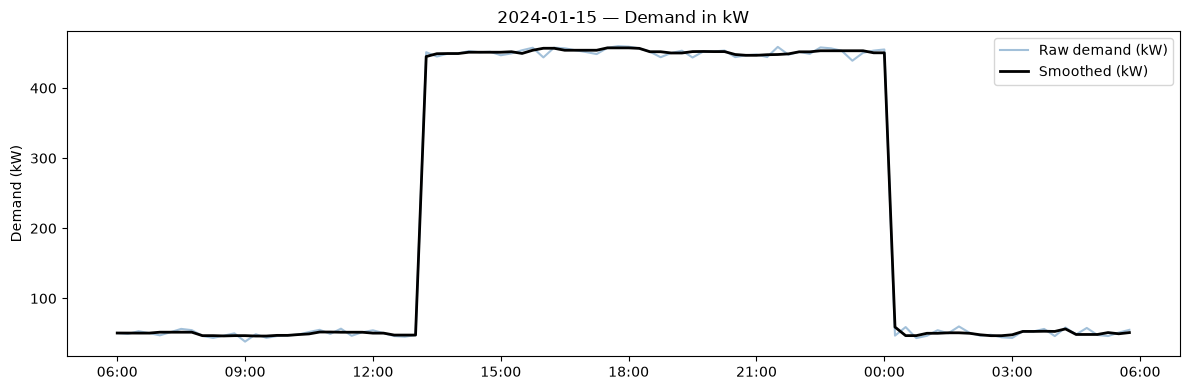

In [39]:
series_raw    = df_day['demand_kw']
series_smooth = apply_smoothing(series_raw, cfg, RESOLUTION_MINUTES)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series_raw.index,    series_raw.values,    alpha=0.5, label='Raw demand (kW)', color='steelblue')
ax.plot(series_smooth.index, series_smooth.values, lw=2,      label='Smoothed (kW)',   color='black')
ax.set_title(f'{INSPECT_DATE} — Demand in kW'
             + (f' (converted from {unit_meta["input_unit"]} × {unit_meta["conversion_factor"]:.4g})'
                if unit_meta['conversion_applied'] else ''))
ax.set_ylabel('Demand (kW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()

### 8c. Baseline Estimation

In [40]:
baseline = estimate_baseline(series_smooth, RESOLUTION_MINUTES, cfg)
print('Baseline result:')
for k, v in baseline.items():
    print(f'  {k}: {v}')

Baseline result:
  baseline_kw: 46.88
  baseline_method: hybrid_sustained
  baseline_period_start: 2024-01-15 02:00:00-06:00
  baseline_period_end: 2024-01-15 03:45:00-06:00
  baseline_period_duration_hours: 1.75
  is_continuous_operation: False
  peak_kw: 457.29
  operating_range_kw: 410.41


### 8d. Demand Normalization

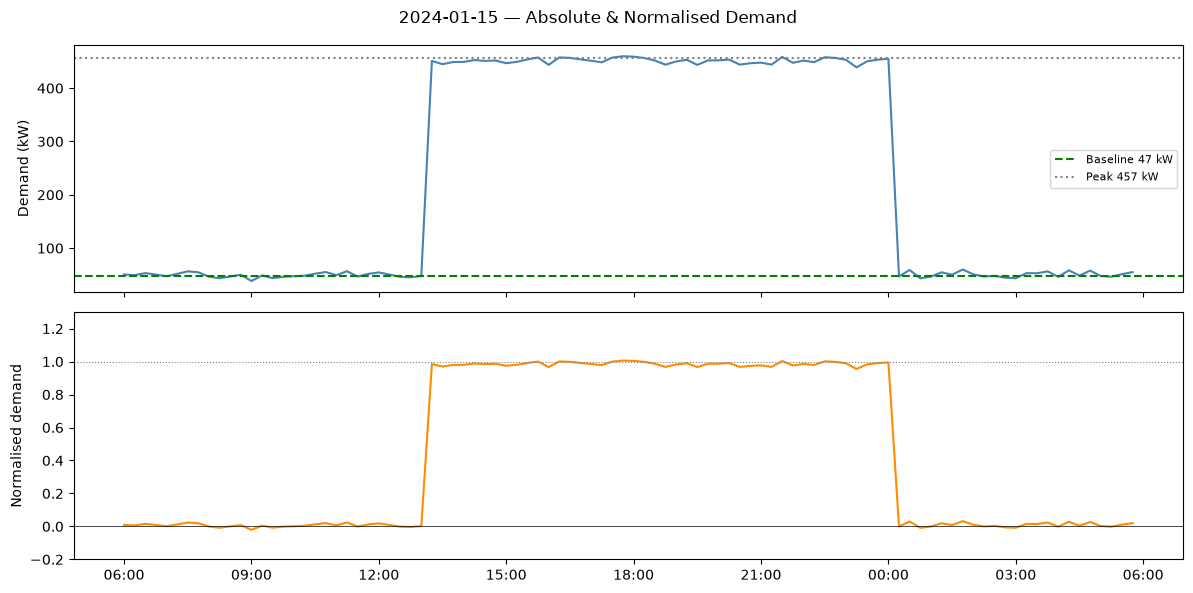

In [41]:
norm = compute_normalized_demand(series_raw, baseline, cfg)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series_raw.index, series_raw.values, color='steelblue')
axes[0].axhline(baseline['baseline_kw'], color='green', ls='--',
                label=f"Baseline {baseline['baseline_kw']:.0f} kW")
axes[0].axhline(baseline['peak_kw'], color='gray', ls=':',
                label=f"Peak {baseline['peak_kw']:.0f} kW")
axes[0].set_ylabel('Demand (kW)')
axes[0].legend(fontsize=8)

axes[1].plot(norm.index, norm.values, color='darkorange')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axhline(1, color='gray', ls=':', lw=0.8)
axes[1].set_ylabel('Normalised demand')
axes[1].set_ylim(-0.2, 1.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.suptitle(f'{INSPECT_DATE} — Absolute & Normalised Demand')
plt.tight_layout()
plt.show()

### 8e. State Detection

In [42]:
states = detect_states(series_smooth, baseline, cfg)

state_counts = states.value_counts()
print('State distribution:')
for state, count in state_counts.items():
    pct = count / len(states) * 100
    hrs = count * RESOLUTION_MINUTES / 60
    print(f'  {state}: {count} intervals ({pct:.1f}%, {hrs:.1f} hr)')

op_periods = detect_operating_periods(states, cfg)
print(f'\nOperating periods: {len(op_periods)}')
for p in op_periods:
    print(f"  #{p['rank']}: {p['start'].strftime('%H:%M')} – {p['end'].strftime('%H:%M')}  "
          f"({p['duration_hours']:.2f} hr)")

State distribution:
  BASELINE: 52 intervals (54.2%, 13.0 hr)
  OPERATING: 44 intervals (45.8%, 11.0 hr)

Operating periods: 1
  #1: 07:15 – 18:15  (11.00 hr)


### 8f. Start & End Detection

In [43]:
start_ev = detect_start(series_smooth, states, baseline, cfg)
end_ev   = detect_end(  series_smooth, states, baseline, cfg)

if start_ev:
    print(f"Start: {start_ev.transition_time.strftime('%H:%M')}  "
          f"(threshold crossing {start_ev.threshold_crossing_time.strftime('%H:%M')})")
    print(f"  Delta: {start_ev.delta_kw:.0f} kW  "
          f"Ramp rate: {start_ev.ramp_rate_kw_per_hr:.0f} kW/hr  "
          f"Confidence: {start_ev.confidence:.2f}  "
          f"Gradual: {start_ev.is_gradual}")
else:
    print('No credible start event detected')

if end_ev:
    print(f"End:   {end_ev.transition_time.strftime('%H:%M')}  "
          f"(threshold crossing {end_ev.threshold_crossing_time.strftime('%H:%M')})")
    print(f"  Delta: {end_ev.delta_kw:.0f} kW  "
          f"Ramp rate: {end_ev.ramp_rate_kw_per_hr:.0f} kW/hr  "
          f"Confidence: {end_ev.confidence:.2f}  "
          f"Gradual: {end_ev.is_gradual}")
else:
    print('No credible end event detected')

Start: 06:30  (threshold crossing 07:15)
  Delta: 397 kW  Ramp rate: 530 kW/hr  Confidence: 0.94  Gradual: False
End:   18:15  (threshold crossing 18:30)
  Delta: 12 kW  Ramp rate: 49 kW/hr  Confidence: 0.53  Gradual: False


### 8g. Ramp Detection

In [44]:
ramp_evs = detect_ramps(series_smooth, baseline, states, cfg)
print(f'Ramp events detected: {len(ramp_evs)}')
for r in ramp_evs:
    print(f"  {r.event_type:4s} | {r.start_time.strftime('%H:%M')}–{r.end_time.strftime('%H:%M')} | "
          f"{r.delta_kw:+.0f} kW | {r.average_ramp_kw_per_hr:.0f} kW/hr | "
          f"op_transition={r.is_operating_transition}")

Ramp events detected: 1
  UP   | 07:00–18:00 | +403 kW | 37 kW/hr | op_transition=True


### 8h. Peak Detection

In [45]:
is_interpolated = df_day.get('is_interpolated', pd.Series(False, index=df_day.index))
peak_evs = detect_peaks(series_raw, is_interpolated, baseline, cfg)

print(f'Peak events detected: {len(peak_evs)}')
for p in peak_evs:
    print(f"  Rank {p.rank}: {p.peak_time.strftime('%H:%M')} | {p.peak_kw:.0f} kW | "
          f"prominence={p.prominence_kw:.0f} kW ({p.prominence_fraction:.0%}) | "
          f"w80={p.width_80_hours:.2f} hr | conf={p.confidence:.2f}")

Peak events detected: 1
  Rank 1: 12:00 | 459 kW | prominence=421 kW (102%) | w80=10.75 hr | conf=1.00


### 8i. Breadth Analysis

In [46]:
op_thresholds = cfg['breadth']['operating_thresholds']
interval_hrs  = RESOLUTION_MINUTES / 60

print('Operating breadth (time above normalised demand threshold):')
for thr in op_thresholds:
    hrs = (norm >= thr).sum() * interval_hrs
    print(f'  above {thr:.0%}: {hrs:.2f} hr')

print('\nPeak breadth:')
for thr in cfg['breadth']['peak_thresholds']:
    hrs = (norm >= thr).sum() * interval_hrs
    print(f'  above {thr:.0%}: {hrs:.2f} hr')

Operating breadth (time above normalised demand threshold):
  above 20%: 11.00 hr
  above 40%: 11.00 hr
  above 60%: 11.00 hr
  above 80%: 11.00 hr
  above 90%: 11.00 hr

Peak breadth:
  above 70%: 11.00 hr
  above 80%: 11.00 hr
  above 90%: 11.00 hr


### 8j. Feature Vector

In [47]:
features = build_daily_features(
    date=INSPECT_DATE,
    meter_id=METER_ID,
    building_id=BUILDING_ID,
    df_day=df_day,
    series_raw=series_raw,
    series_smooth=series_smooth,
    states=states,
    baseline_result=baseline,
    quality=quality,
    start_event=start_ev,
    end_event=end_ev,
    ramp_events=ramp_evs,
    peak_events=peak_evs,
    operating_periods=op_periods,
    norm_demand=norm,
    cfg=cfg,
    resolution_minutes=RESOLUTION_MINUTES,
)

print('Feature vector (selected fields):')
selected = [
    'baseline_kw', 'average_kw', 'peak_kw',
    'probable_start_time', 'probable_end_time',
    'startup_delta_kw', 'startup_ramp_kw_per_hr', 'start_confidence',
    'total_operating_duration_hours', 'operating_period_count',
    'peak_width_70_hours', 'peak_width_80_hours', 'peak_width_90_hours',
    'peak_to_average_ratio', 'load_factor', 'cv',
    'ramp_event_count', 'secondary_peak_count',
]
for k in selected:
    print(f'  {k}: {features.get(k)}')

Feature vector (selected fields):
  baseline_kw: 46.88
  average_kw: 233.9207
  peak_kw: 459.01
  probable_start_time: 2024-01-15T06:30:00-06:00
  probable_end_time: 2024-01-15T18:15:00-06:00
  startup_delta_kw: 397.24
  startup_ramp_kw_per_hr: 529.65
  start_confidence: 0.9444
  total_operating_duration_hours: 11.0
  operating_period_count: 1
  peak_width_70_hours: 10.75
  peak_width_80_hours: 10.75
  peak_width_90_hours: 10.75
  peak_to_average_ratio: 1.9656
  load_factor: 0.5087
  cv: 0.8595
  ramp_event_count: 1
  secondary_peak_count: 0


### 8k. Classification

In [48]:
classification = classify_day(features, cfg)
print(f"Primary class:  {classification['primary_class']}")
print(f"Attributes:     {classification['attributes']}")
print(f"Confidence:     {classification['classification_confidence']:.2f}")
print(f"Notes:          {classification['classification_notes']}")

Primary class:  MORNING_START
Attributes:     ['rapid_start', 'long_operating_duration', 'broad_peak', 'high_intraday_variability']
Confidence:     0.87
Notes:          Classified from rule-based logic.


### 8l. Diagnostic Visualization

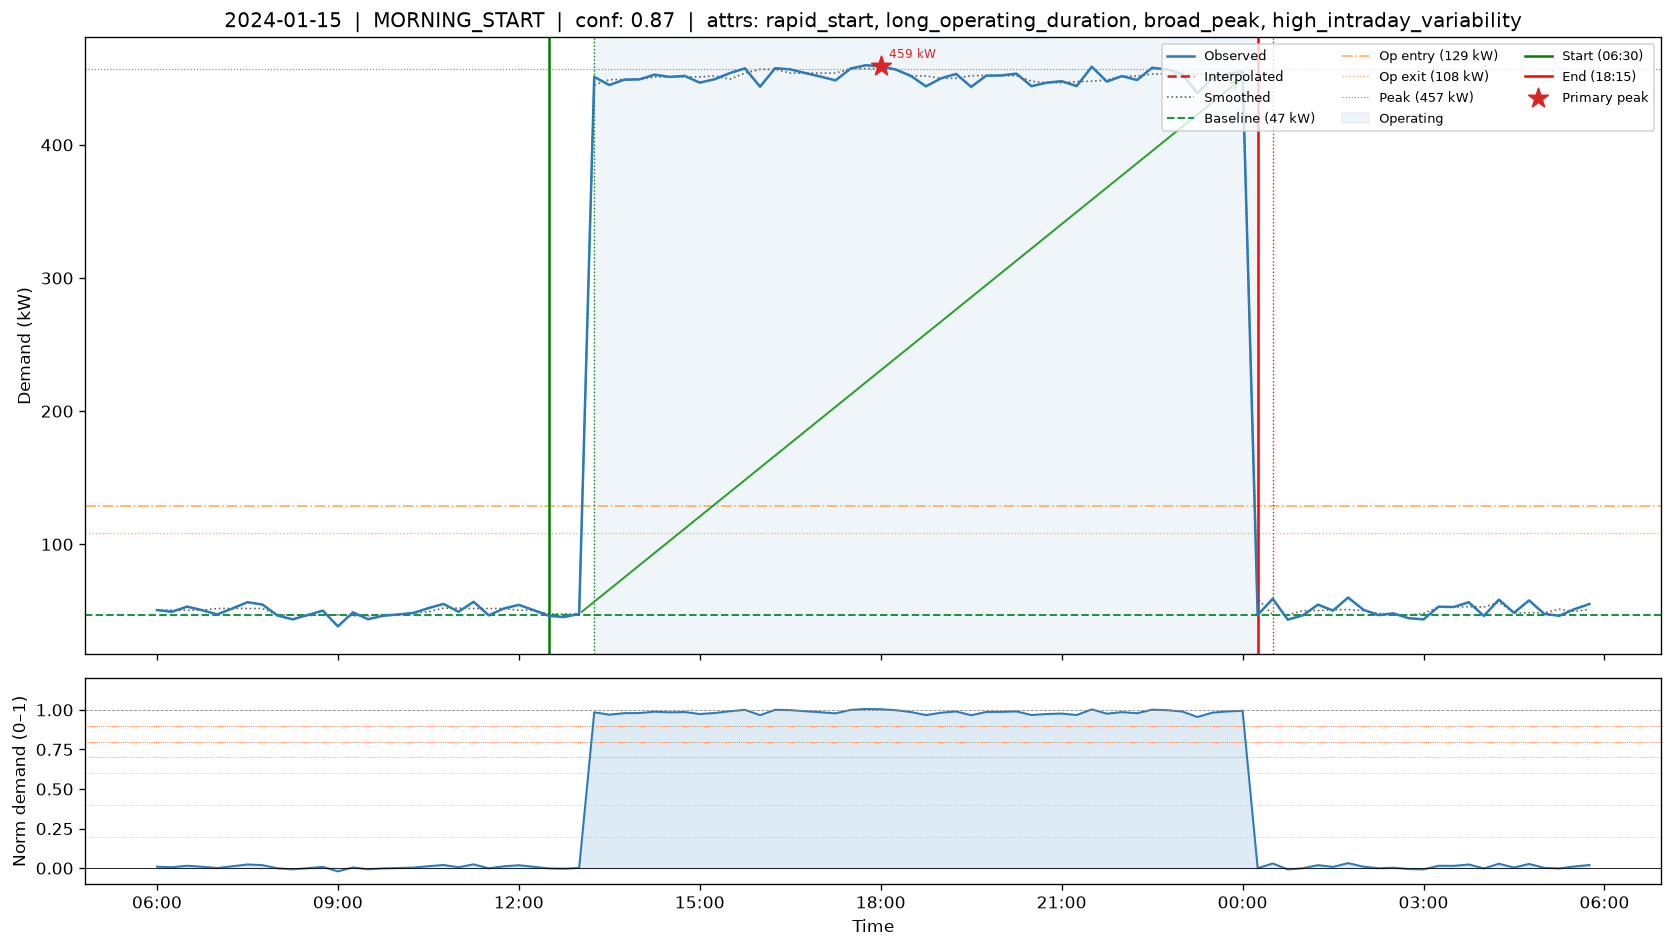

In [49]:
fig = plot_daily_profile(
    date=INSPECT_DATE,
    df_day=df_day,
    series_smooth=series_smooth,
    norm_demand=norm,
    states=states,
    baseline_result=baseline,
    start_event=start_ev,
    end_event=end_ev,
    ramp_events=ramp_evs,
    peak_events=peak_evs,
    operating_periods=op_periods,
    features=features,
    classification=classification,
    cfg=cfg,
)
plt.show()

## 9. Full Population Run

Runs the complete pipeline (including unit conversion) on all days and collects results.

In [50]:
# Note: run_pipeline calls convert_units internally using cfg['input']['unit'],
# so the same config that drove the step-through above applies here too.
df_reload = load_demand_data(source, cfg)   # fresh load so pipeline owns the df

results = run_pipeline(df_reload, cfg, meter_id=METER_ID, building_id=BUILDING_ID, verbose=True)

daily_df    = results['daily_df']
ramp_df     = results['ramp_df']
peak_df     = results['peak_df']
interval_df = results['interval_df']

print(f'\nResults summary:')
print(f'  Daily features:   {len(daily_df)} rows × {len(daily_df.columns)} columns')
print(f'  Ramp events:      {len(ramp_df)}')
print(f'  Peak events:      {len(peak_df)}')
print(f'  Interval records: {len(interval_df)}')

[pipeline] Resolution detected: 15.0 min | Duplicates: 0 | Irregular: 0
[pipeline] Regularised: 96 intervals
[pipeline] Days to analyse: 1
[pipeline]   2024-01-15 (96 intervals) → MORNING_START (conf 0.87)

Results summary:
  Daily features:   1 rows × 75 columns
  Ramp events:      1
  Peak events:      1
  Interval records: 96


In [51]:
display_cols = [
    'date', 'primary_class', 'classification_confidence',
    'baseline_kw', 'peak_kw', 'probable_start_time',
    'total_operating_duration_hours', 'dq_quality_status',
]
available = [c for c in display_cols if c in daily_df.columns]
daily_df[available]

,date,primary_class,classification_confidence,baseline_kw,peak_kw,probable_start_time,total_operating_duration_hours,dq_quality_status
0,2024-01-15,MORNING_START,0.8693,46.88,459.01,2024-01-15T06:30:00-06:00,11.0,GOOD


## 10. Population-Level Summaries

In [52]:
if len(daily_df) > 1:
    fig = plot_population_summary(daily_df, cfg)
    plt.show()
else:
    print('Only one day in dataset — population summary requires multiple days.')

Only one day in dataset — population summary requires multiple days.


## 11. Unit Conversion Verification

Load the same profile in both kW and kWh and confirm the analytical results are identical.  
This verifies that the conversion factor is applied correctly.

In [53]:
from copy import deepcopy

kw_file  = repo_root / 'data' / 'examples' / 'office_building_15min.csv'
kwh_file = repo_root / 'data' / 'examples' / 'office_building_15min_kwh.csv'

if not kw_file.exists() or not kwh_file.exists():
    print('Example files not found — run the data generation cell in the README first.')
else:
    cfg_kw  = deepcopy(cfg)
    cfg_kwh = deepcopy(cfg)
    cfg_kw['input']['unit']  = 'kW'
    cfg_kwh['input']['unit'] = 'kWh'
    cfg_kwh['input']['demand_col'] = 'demand_kwh'

    res_kw  = run_pipeline(load_demand_data(kw_file,  cfg_kw),  cfg_kw,  verbose=False)
    res_kwh = run_pipeline(load_demand_data(kwh_file, cfg_kwh), cfg_kwh, verbose=False)

    compare_cols = ['baseline_kw', 'peak_kw', 'average_kw',
                    'primary_class', 'probable_start_time']
    available = [c for c in compare_cols if c in res_kw['daily_df'].columns]

    print('kW  input results:')
    print(res_kw['daily_df'][available].to_string(index=False))
    print('\nkWh input results (should match after conversion):')
    print(res_kwh['daily_df'][available].to_string(index=False))

    kw_vals  = res_kw['daily_df']['peak_kw'].values
    kwh_vals = res_kwh['daily_df']['peak_kw'].values
    match = all(abs(a - b) < 0.01 for a, b in zip(kw_vals, kwh_vals)
                if a is not None and b is not None)
    print(f'\nPeak kW values match: {match}')

kW  input results:
 baseline_kw  peak_kw  average_kw primary_class       probable_start_time
       46.88   459.01    233.9207 MORNING_START 2024-01-15T06:30:00-06:00
       46.88   459.01    233.9207 MORNING_START 2024-01-16T06:30:00-06:00
       46.88   459.01    233.9207 MORNING_START 2024-01-17T06:30:00-06:00

kWh input results (should match after conversion):
 baseline_kw  peak_kw  average_kw primary_class       probable_start_time
       46.88   459.01    233.9207 MORNING_START 2024-01-15T06:30:00-06:00
       46.88   459.01    233.9207 MORNING_START 2024-01-16T06:30:00-06:00
       46.88   459.01    233.9207 MORNING_START 2024-01-17T06:30:00-06:00

Peak kW values match: True


## 12. Synthetic Test Suite

In [54]:
test_results = []

for scenario_name in sorted(SCENARIOS.keys()):
    try:
        df_syn, expected = generate_synthetic_day(scenario_name)
        df_loaded = load_demand_data(df_syn.reset_index(), cfg)
        pipe_out  = run_pipeline(df_loaded, cfg, verbose=False)
        day_row   = pipe_out['daily_df'].iloc[0].to_dict()

        pass_flag = True
        notes     = []

        if 'primary_class' in expected:
            if day_row.get('primary_class') != expected['primary_class']:
                pass_flag = False
                notes.append(f"class: got {day_row.get('primary_class')!r} expected {expected['primary_class']!r}")

        if 'primary_class_in' in expected:
            if day_row.get('primary_class') not in expected['primary_class_in']:
                pass_flag = False
                notes.append(f"class not in {expected['primary_class_in']}")

        if 'is_continuous_operation' in expected:
            if bool(day_row.get('is_continuous_operation')) != expected['is_continuous_operation']:
                pass_flag = False
                notes.append(f"continuous: got {day_row.get('is_continuous_operation')}")

        if 'attributes_include' in expected:
            got_attrs = day_row.get('attributes', [])
            for attr in expected['attributes_include']:
                if attr not in got_attrs:
                    pass_flag = False
                    notes.append(f"missing attr: {attr}")

        test_results.append({
            'scenario':   scenario_name,
            'status':     'PASS' if pass_flag else 'FAIL',
            'class':      day_row.get('primary_class', '?'),
            'confidence': round(day_row.get('classification_confidence', 0), 2),
            'notes':      '; '.join(notes) if notes else '',
        })

    except Exception as e:
        test_results.append({
            'scenario': scenario_name, 'status': 'ERROR',
            'class': '', 'confidence': 0, 'notes': str(e),
        })

test_df = pd.DataFrame(test_results)
print(f"Tests: {len(test_df)} total  |  "
      f"PASS: {(test_df.status=='PASS').sum()}  |  "
      f"FAIL: {(test_df.status=='FAIL').sum()}  |  "
      f"ERROR: {(test_df.status=='ERROR').sum()}")
test_df

Tests: 21 total  |  PASS: 18  |  FAIL: 2  |  ERROR: 1


,scenario,status,class,confidence,notes
0,247_operation,PASS,CONTINUOUS,0.67,
1,abrupt_shutdown,FAIL,MORNING_START,0.74,missing attr: rapid_shutdown
2,broad_peak,PASS,MORNING_START,0.74,
3,classic_morning_startup,PASS,MORNING_START,0.87,
4,demand_spike,PASS,MORNING_START,0.73,
5,dst_fall,PASS,EARLY_START,0.74,
6,dst_spring,PASS,MORNING_START,0.74,
7,flat_continuous,PASS,CONTINUOUS,0.50,
8,gradual_shutdown,PASS,MORNING_START,0.84,
9,gradual_startup,FAIL,EARLY_START,0.76,missing attr: gradual_start


## 13. Export

In [55]:
daily_df.to_csv(OUTPUT_DIR / 'daily_features.csv', index=False)

for name, df_out in [('ramp_events', ramp_df), ('peak_events', peak_df)]:
    if not df_out.empty:
        out = df_out.copy()
        for col in out.select_dtypes(include='datetimetz').columns:
            out[col] = out[col].astype(str)
        out.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)

if not interval_df.empty:
    interval_df.to_csv(OUTPUT_DIR / 'interval_analysis.csv')

print(f'Exports written to: {OUTPUT_DIR}')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}: {f.stat().st_size:,} bytes')

Exports written to: /Users/egeriicw/Personal-Projects/load-demand-and-flexibility-analysis/output
  daily_features.csv: 2,135 bytes
  interval_analysis.csv: 11,206 bytes
  peak_events.csv: 261 bytes
  ramp_events.csv: 319 bytes


## 14. Validation Examples — Visual Inspection

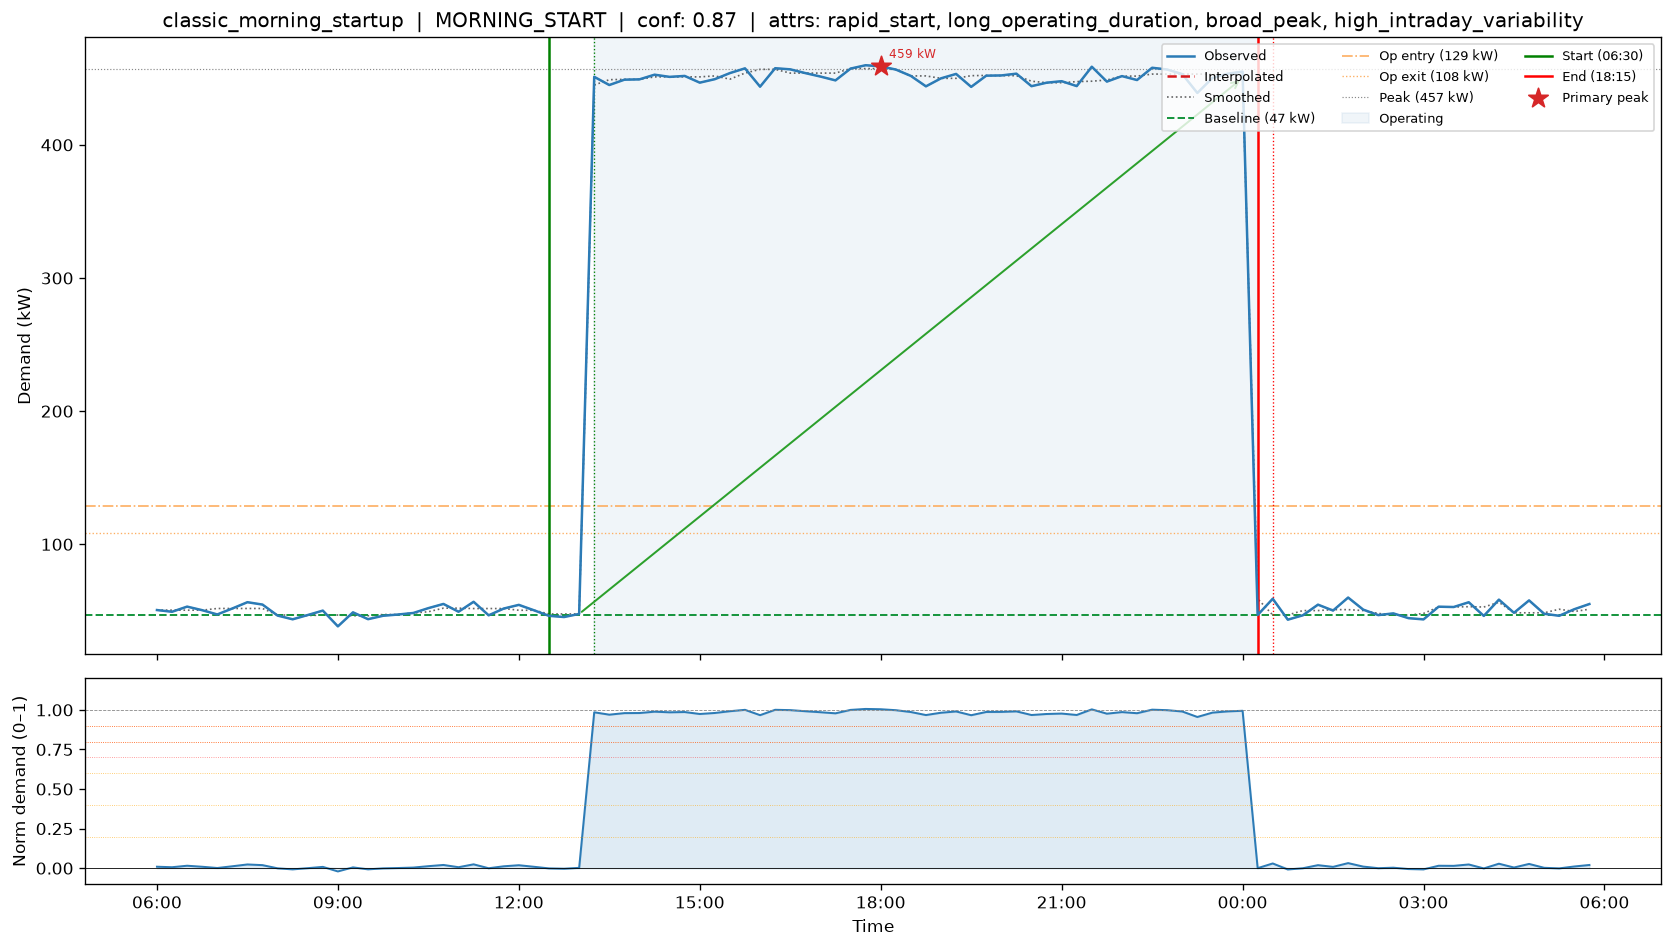

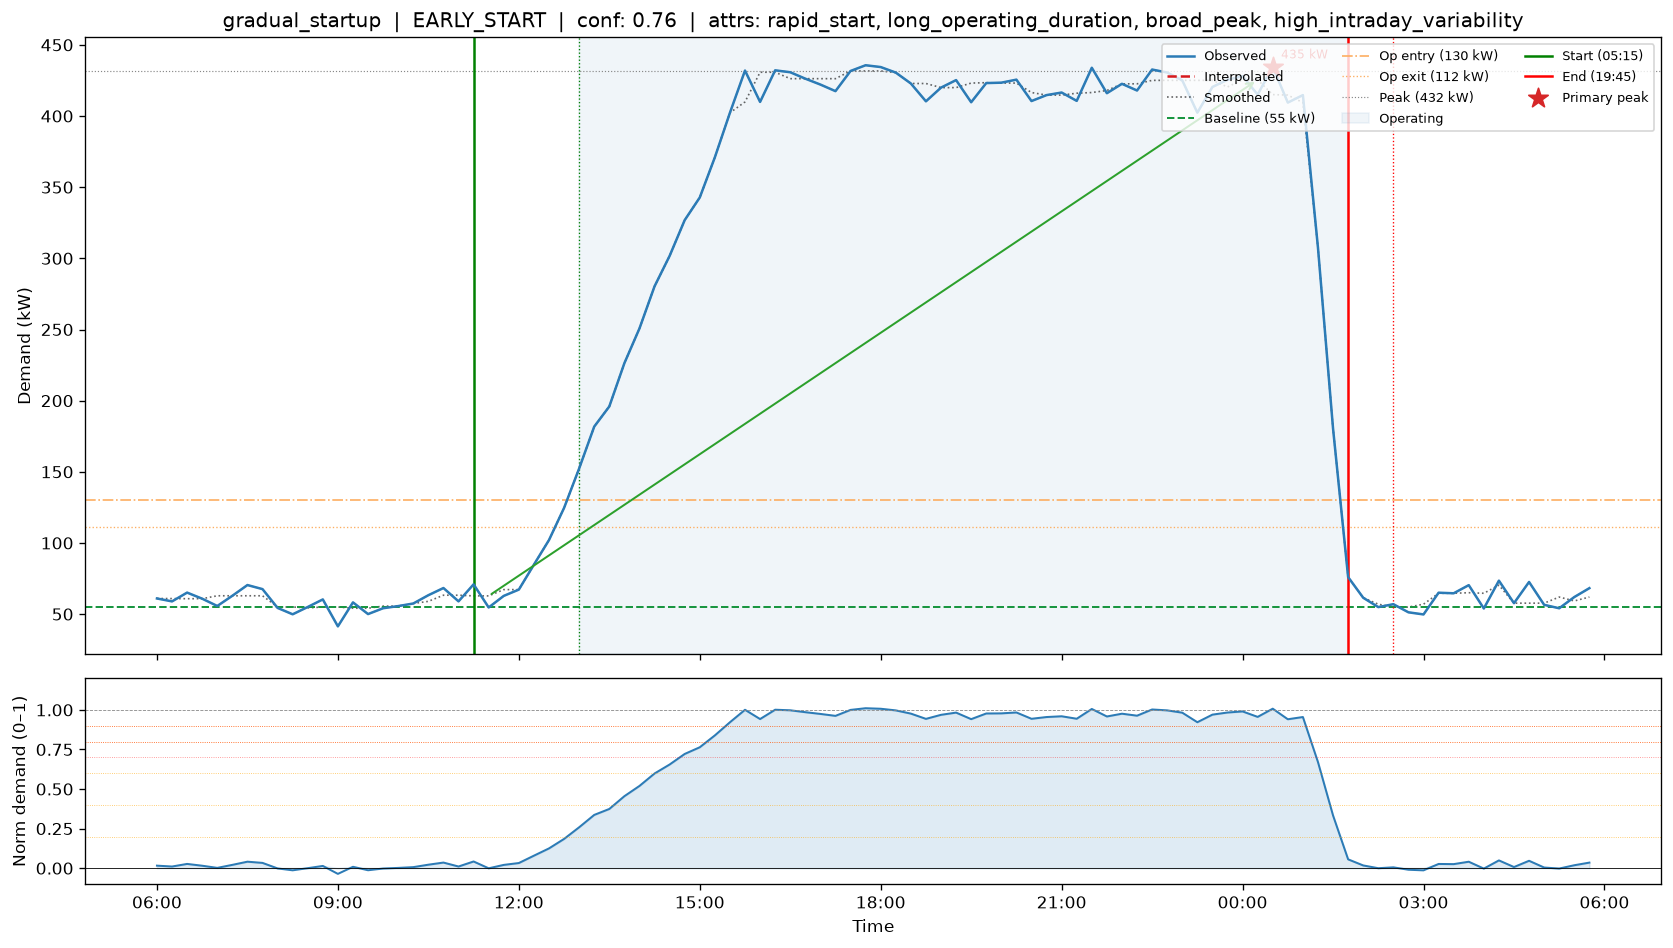

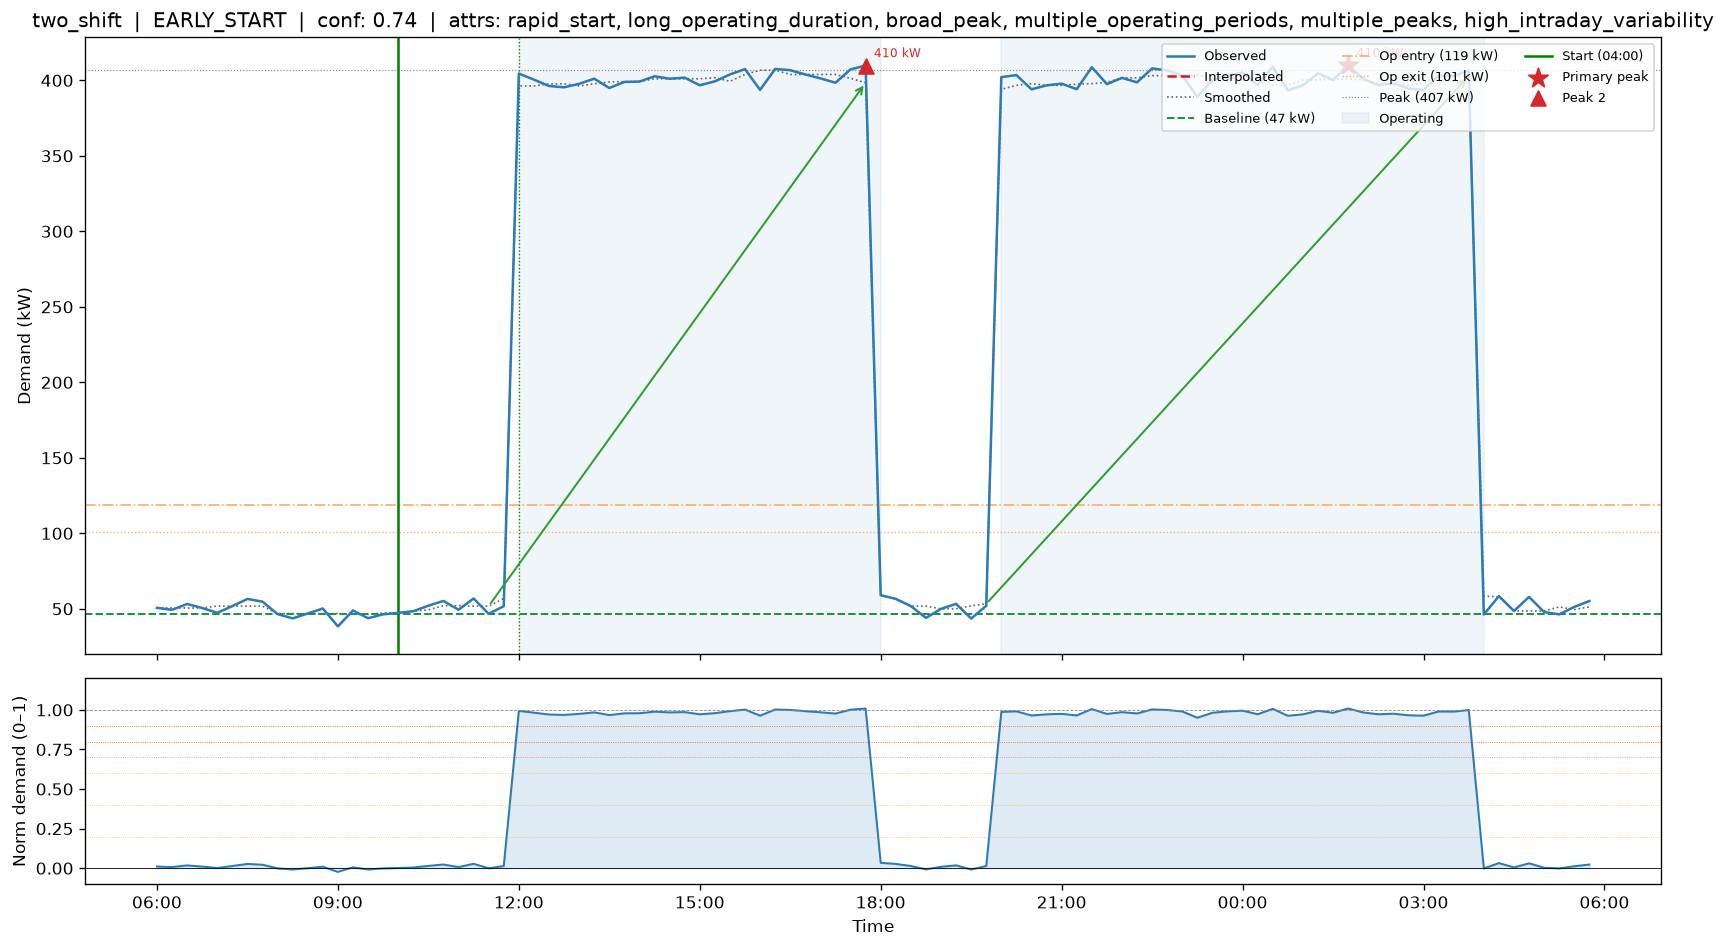

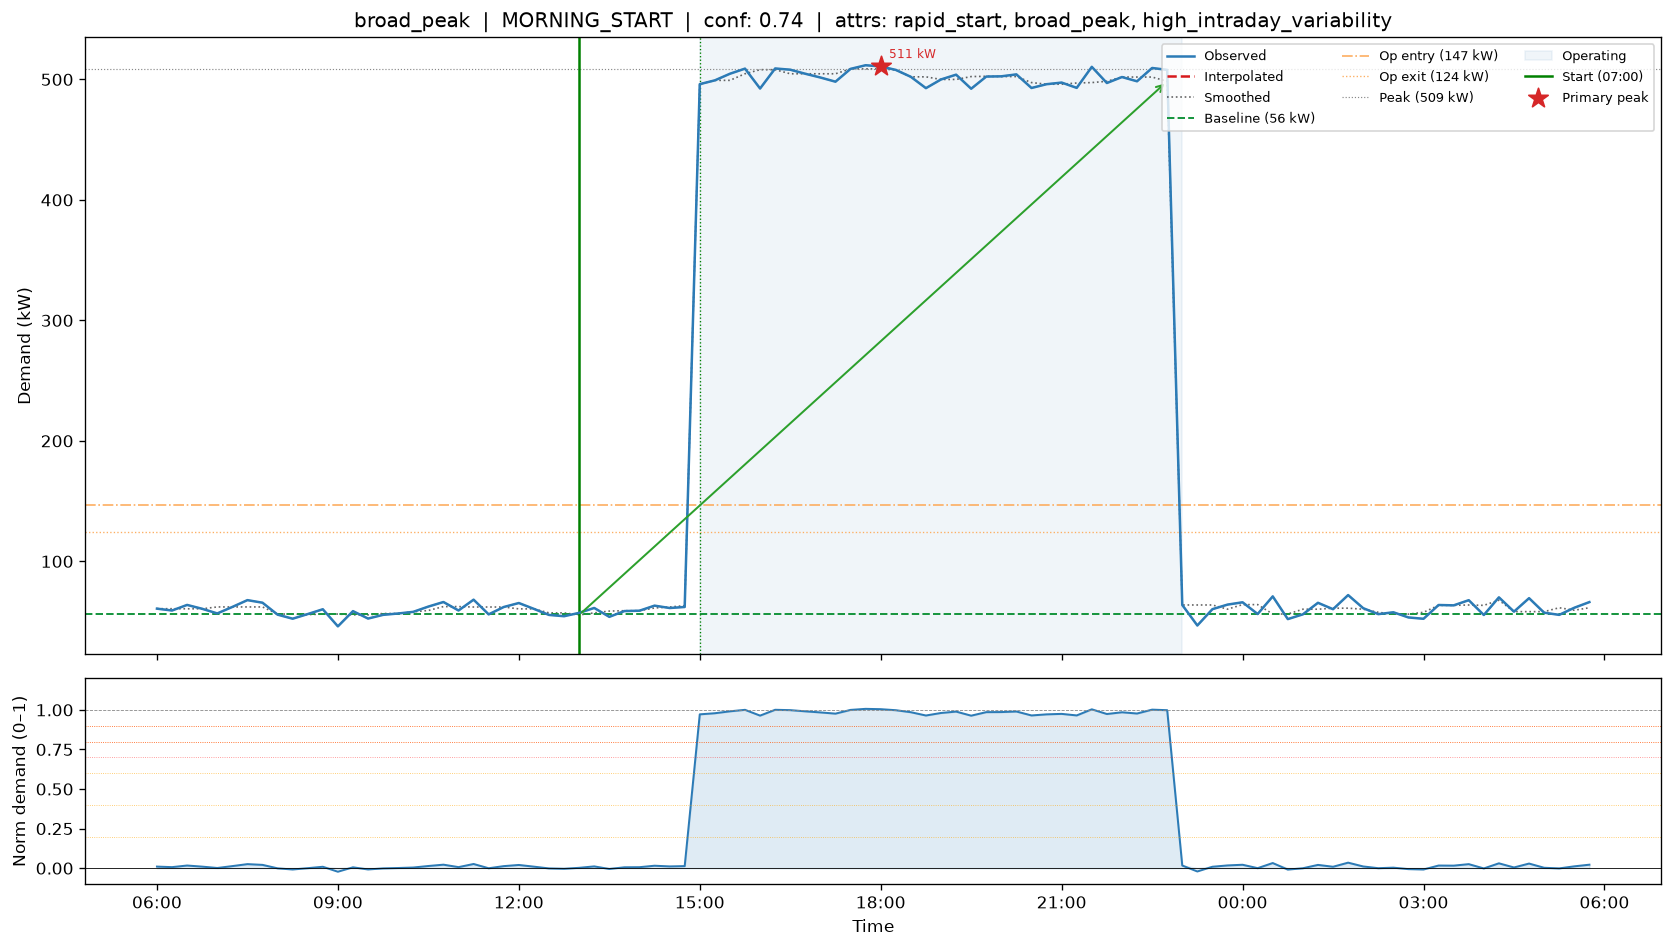

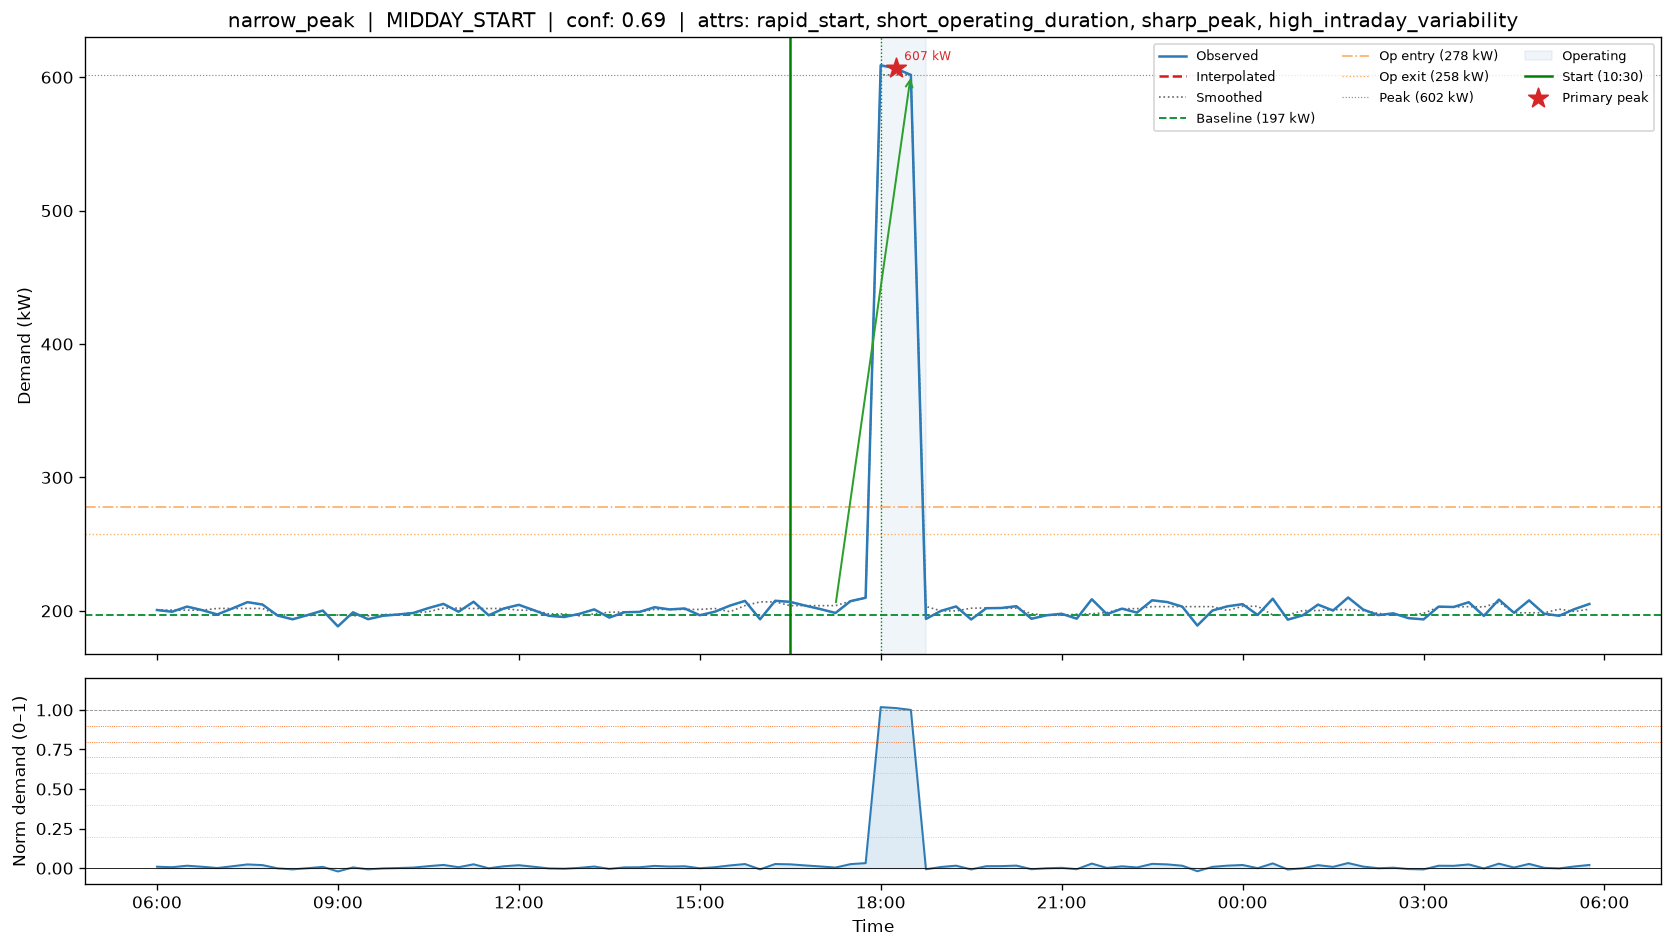

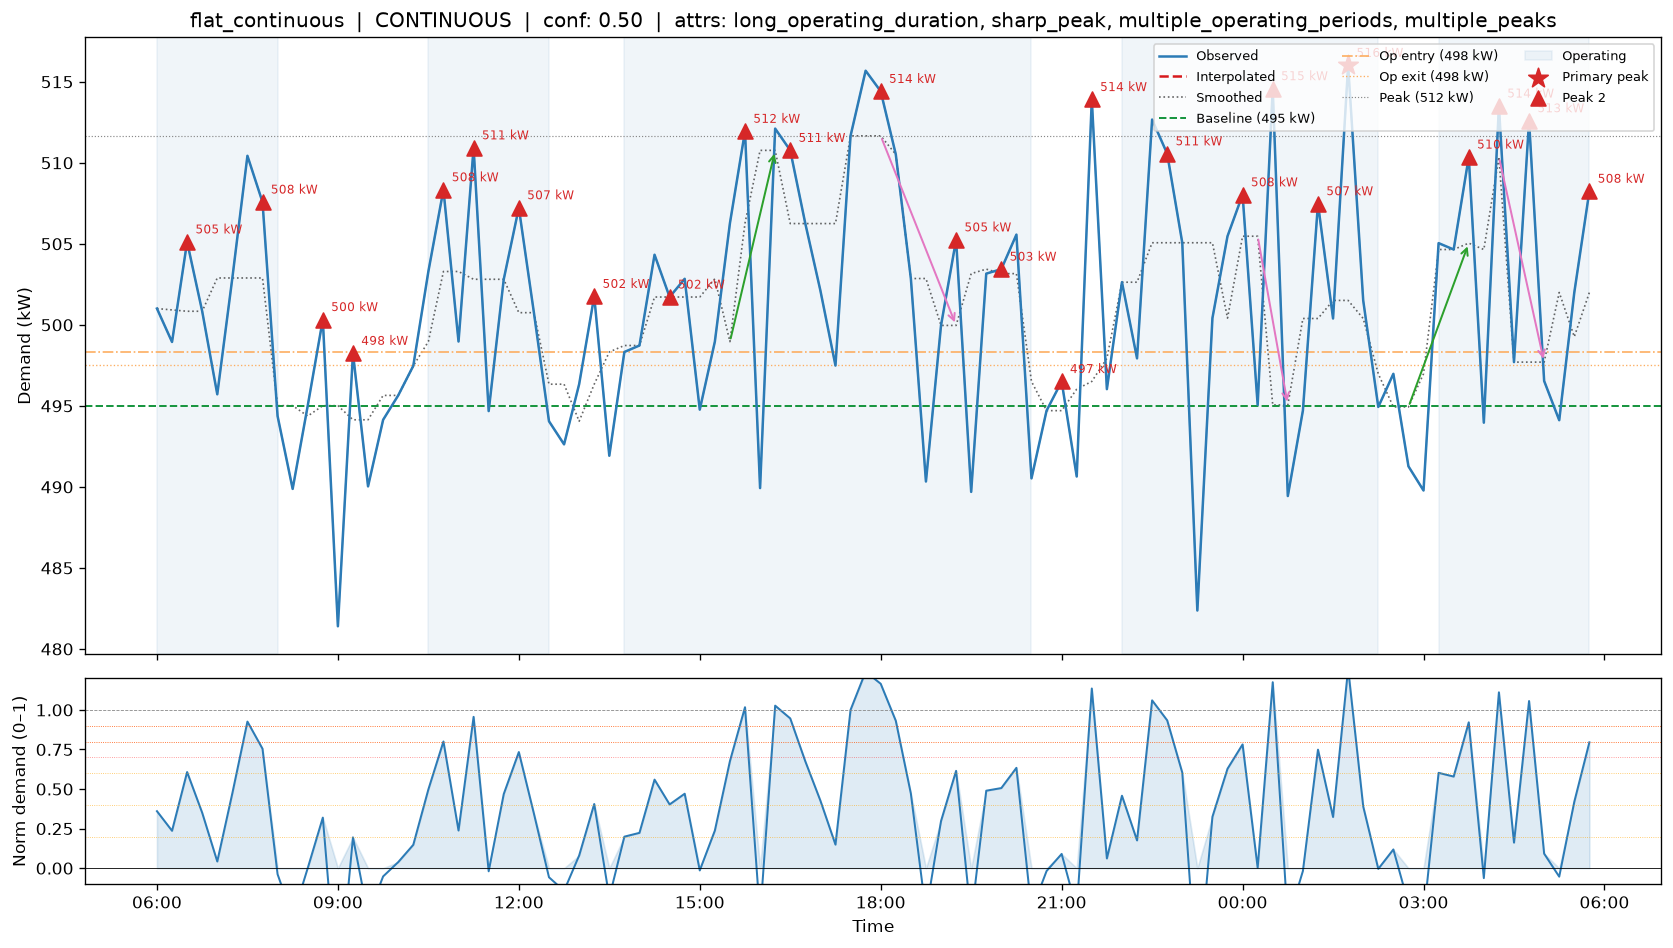

In [56]:
VALIDATION_SCENARIOS = [
    'classic_morning_startup',
    'gradual_startup',
    'two_shift',
    'broad_peak',
    'narrow_peak',
    'flat_continuous',
]

for sc in VALIDATION_SCENARIOS:
    try:
        df_syn, exp = generate_synthetic_day(sc)
        df_l = load_demand_data(df_syn.reset_index(), cfg)

        validation_v = validate_input(df_l, cfg)
        res_v = validation_v['detected_resolution_minutes']
        df_l, _ = convert_units(df_l, res_v, cfg)

        df_r  = regularize(df_l, res_v, cfg)
        days  = segment_days(df_r)
        dk    = sorted(days.keys())[0]
        df_d  = days[dk]

        sr = df_d['demand_kw']
        ss = apply_smoothing(sr, cfg, res_v)
        bl = estimate_baseline(ss, res_v, cfg)
        nm = compute_normalized_demand(sr, bl, cfg)
        st = detect_states(ss, bl, cfg)
        se = detect_start(ss, st, bl, cfg)
        ee = detect_end(ss, st, bl, cfg)
        re = detect_ramps(ss, bl, st, cfg)
        pe = detect_peaks(sr, df_d.get('is_interpolated', pd.Series(False, index=df_d.index)), bl, cfg)
        op = detect_operating_periods(st, cfg)
        ft = build_daily_features(
            date=dk, meter_id=sc, building_id='VAL',
            df_day=df_d, series_raw=sr, series_smooth=ss,
            states=st, baseline_result=bl,
            quality=assess_quality(df_d, res_v, cfg),
            start_event=se, end_event=ee, ramp_events=re, peak_events=pe,
            operating_periods=op, norm_demand=nm, cfg=cfg, resolution_minutes=res_v
        )
        cl = classify_day(ft, cfg)

        fig = plot_daily_profile(
            date=sc, df_day=df_d, series_smooth=ss, norm_demand=nm,
            states=st, baseline_result=bl, start_event=se, end_event=ee,
            ramp_events=re, peak_events=pe, operating_periods=op,
            features=ft, classification=cl, cfg=cfg,
        )
        plt.show()
    except Exception as exc:
        print(f'  {sc}: ERROR — {exc}')